# 06 — Regression & Forecasting: AI Adoption Trends 2019-2028

**Goal:** Build regression models to understand historical AI adoption drivers and forecast national AI adoption rates and investment levels through 2028.

**Models evaluated:**
1. Linear Regression (baseline)
2. Polynomial Regression (degree 2 & 3)
3. Multi-feature Ridge Regression
4. Gradient Boosting Regressor

---

## 1. Load National Time Series Data

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

OLIVE     = '#6B7C3A'
OLIVE_LT  = '#A8B85A'
AMBER     = '#C47A28'
BLUE      = '#2874A6'
PURPLE    = '#8B5E8B'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load national time series
NATIONAL_PATH = '../data/raw/sme_ai_adoption_national.csv'

if os.path.exists(NATIONAL_PATH):
    df_national = pd.read_csv(NATIONAL_PATH)
    print(f'Loaded national time series: {df_national.shape}')
    print(df_national.head())
else:
    # Synthesize plausible national-level data if file doesn't exist yet
    print(f'File {NATIONAL_PATH} not found — generating synthetic national data.')
    df_national = pd.DataFrame({
        'year':           [2019, 2020, 2021, 2022, 2023, 2024],
        'adoption_rate':  [0.128, 0.152, 0.198, 0.267, 0.341, 0.423],
        'avg_ai_investment_usd': [18200, 22400, 31500, 47800, 68300, 94500],
        'avg_digital_maturity':  [2.1, 2.3, 2.6, 2.9, 3.2, 3.6],
        'pct_cloud_adopted':     [0.31, 0.38, 0.47, 0.56, 0.65, 0.73],
        'avg_tech_invest_pct':   [3.2, 3.6, 4.1, 4.7, 5.3, 6.0],
        'avg_revenue_m_usd':     [5.4, 4.9, 5.8, 6.7, 7.3, 8.1]
    })
    os.makedirs('../data/raw', exist_ok=True)
    df_national.to_csv(NATIONAL_PATH, index=False)
    print('Synthetic data created and saved.')

df_national.head()

Loaded national time series: (6, 7)
   year  adoption_rate  avg_ai_investment_usd  avg_productivity_gain_pct  \
0  2019         0.2655                97057.0                      25.64   
1  2020         0.3009               147658.0                      26.83   
2  2021         0.3686                79081.0                      26.25   
3  2022         0.4422               161430.0                      26.25   
4  2023         0.5014                87573.0                      25.74   

   avg_revenue_growth_pct  pct_cloud_adopted  n_companies  
0                    9.57             0.2695          501  
1                   11.10             0.4087          575  
2                   10.63             0.4418          765  
3                   11.16             0.5544          900  
4                   12.65             0.6166         1111  


,year,adoption_rate,avg_ai_investment_usd,avg_productivity_gain_pct,avg_revenue_growth_pct,pct_cloud_adopted,n_companies
0,2019,0.2655,97057.0,25.64,9.57,0.2695,501
1,2020,0.3009,147658.0,26.83,11.10,0.4087,575
2,2021,0.3686,79081.0,26.25,10.63,0.4418,765
3,2022,0.4422,161430.0,26.25,11.16,0.5544,900
4,2023,0.5014,87573.0,25.74,12.65,0.6166,1111


## 2. Load Industry Time Series Data

In [3]:
TIMESERIES_PATH = '../data/raw/sme_ai_adoption_timeseries.csv'

if os.path.exists(TIMESERIES_PATH):
    df_ts = pd.read_csv(TIMESERIES_PATH)
    print(f'Loaded industry time series: {df_ts.shape}')
else:
    print(f'File {TIMESERIES_PATH} not found — generating synthetic industry data.')

    # Load main dataset and aggregate by year + industry
    CLEAN_PATH = '../data/processed/sme_clean.csv'
    RAW_PATH   = '../data/raw/sme_ai_adoption_main.csv'
    src = pd.read_csv(CLEAN_PATH if os.path.exists(CLEAN_PATH) else RAW_PATH)

    df_ts = (
        src.groupby(['year', 'industry'])
        .agg(
            adoption_rate=('ai_adopted', 'mean'),
            avg_ai_investment_usd=('ai_investment_usd', 'mean'),
            n_smes=('company_id', 'count')
        )
        .reset_index()
    )
    df_ts.to_csv(TIMESERIES_PATH, index=False)
    print(f'Aggregated industry time series saved. Shape: {df_ts.shape}')

print('Industries:', df_ts['industry'].unique().tolist() if 'industry' in df_ts.columns else 'N/A')
df_ts.head()

Loaded industry time series: (60, 6)
Industries: ['Technology & Software', 'Finance & Insurance', 'Healthcare & Biotech', 'Retail & E-commerce', 'Manufacturing', 'Professional Services', 'Education', 'Hospitality & Food', 'Construction', 'Agriculture']


,year,industry,adoption_rate,avg_ai_investment_usd,avg_productivity_gain_pct,n_companies
0,2019,Technology & Software,0.5263,58808.0,30.06,57
1,2019,Finance & Insurance,0.4783,104047.0,25.48,46
2,2019,Healthcare & Biotech,0.2000,40285.0,24.70,45
3,2019,Retail & E-commerce,0.2708,310271.0,22.09,48
4,2019,Manufacturing,0.3469,94894.0,22.11,49


## 3. Plot Historical Trend — National Adoption Rate 2019-2024

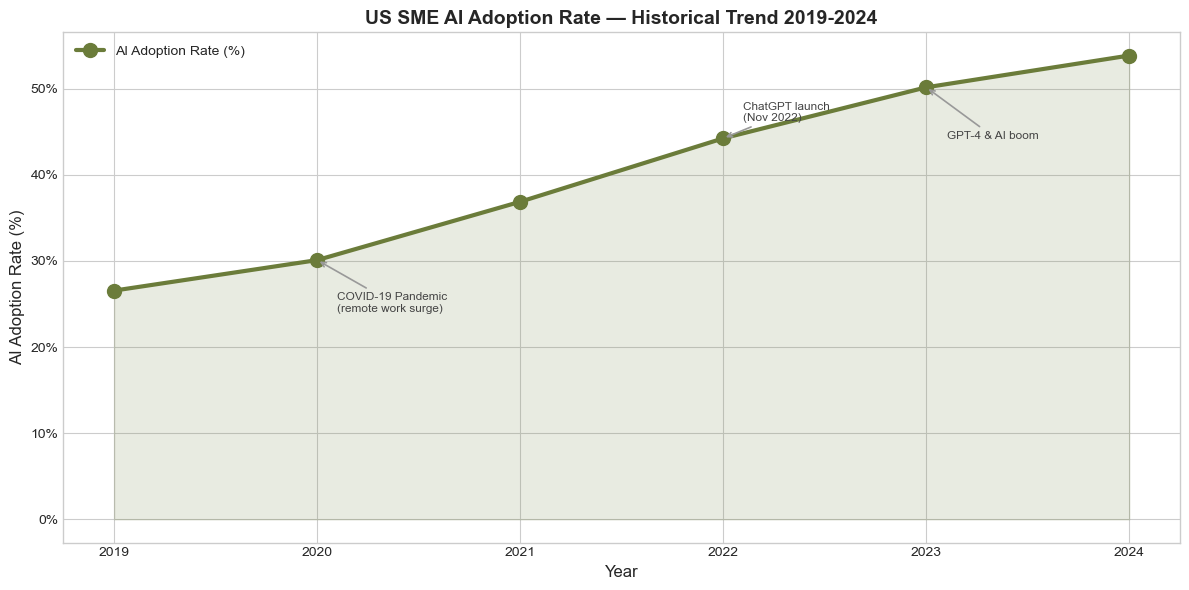

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_national['year'], df_national['adoption_rate'] * 100,
    color=OLIVE, linewidth=3, marker='o', markersize=10, label='AI Adoption Rate (%)'
)

# Fill under curve
ax.fill_between(df_national['year'], df_national['adoption_rate'] * 100, alpha=0.15, color=OLIVE)

# Annotate key events
events = {
    2020: ('COVID-19 Pandemic\n(remote work surge)', -6),
    2022: ('ChatGPT launch\n(Nov 2022)', +2),
    2023: ('GPT-4 & AI boom', -6)
}
for yr, (label, offset) in events.items():
    yr_data = df_national[df_national['year'] == yr]
    if not yr_data.empty:
        rate = yr_data['adoption_rate'].values[0] * 100
        ax.annotate(
            label, xy=(yr, rate), xytext=(yr + 0.1, rate + offset),
            fontsize=8.5, color='#444',
            arrowprops=dict(arrowstyle='->', color='#999', lw=1.2)
        )

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AI Adoption Rate (%)', fontsize=12)
ax.set_title('US SME AI Adoption Rate — Historical Trend 2019-2024', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_xticks(df_national['year'])
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../assets/06_historical_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Model 1: Linear Regression Baseline

=== Linear Regression ===
  Coeff: 0.0583  |  Intercept: -117.3698
  RMSE:  0.0103  |  MAE: 0.0099  |  R²: 0.9893
  Forecast: {2025: np.float64(0.607), 2026: np.float64(0.665), 2027: np.float64(0.723), 2028: np.float64(0.782)}


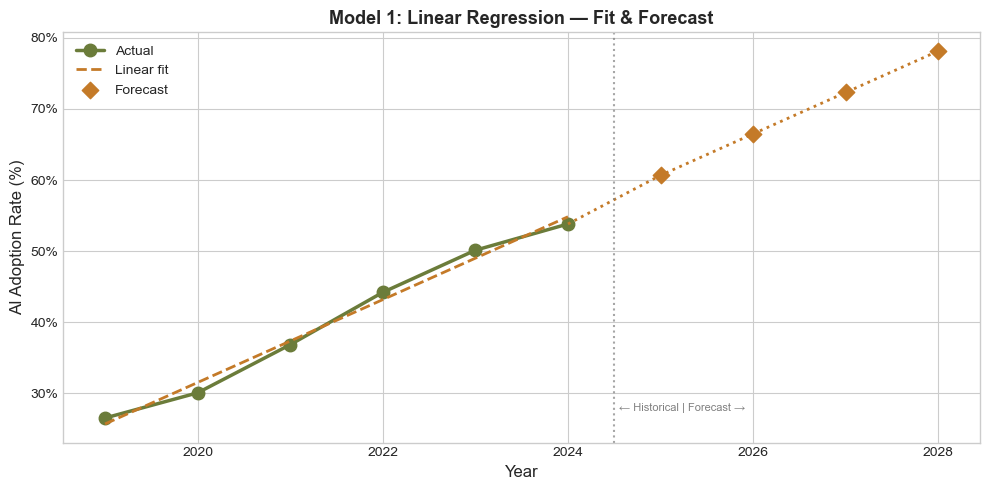

In [5]:
# Prepare data
years_hist  = df_national['year'].values.reshape(-1, 1)
rates_hist  = df_national['adoption_rate'].values
years_fore  = np.array([2025, 2026, 2027, 2028]).reshape(-1, 1)
years_all   = np.vstack([years_hist, years_fore])

# Fit linear model
lr = LinearRegression()
lr.fit(years_hist, rates_hist)

lr_pred_hist = lr.predict(years_hist)
lr_pred_fore = lr.predict(years_fore)

lr_rmse = np.sqrt(mean_squared_error(rates_hist, lr_pred_hist))
lr_mae  = mean_absolute_error(rates_hist, lr_pred_hist)
lr_r2   = r2_score(rates_hist, lr_pred_hist)

print('=== Linear Regression ===')
print(f'  Coeff: {lr.coef_[0]:.4f}  |  Intercept: {lr.intercept_:.4f}')
print(f'  RMSE:  {lr_rmse:.4f}  |  MAE: {lr_mae:.4f}  |  R²: {lr_r2:.4f}')
print(f'  Forecast: {dict(zip([2025,2026,2027,2028], lr_pred_fore.round(3)))}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_national['year'], rates_hist * 100, 'o-', color=OLIVE, lw=2.5, label='Actual', ms=9)
ax.plot(df_national['year'], lr_pred_hist * 100, '--', color=AMBER, lw=2, label='Linear fit')
ax.plot([2024, 2025, 2026, 2027, 2028],
        np.concatenate([[rates_hist[-1]], lr_pred_fore]) * 100,
        ':', color=AMBER, lw=2)
ax.scatter([2025, 2026, 2027, 2028], lr_pred_fore * 100, color=AMBER, marker='D', s=70, zorder=5, label='Forecast')
ax.axvline(x=2024.5, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.text(2024.55, min(rates_hist) * 100 + 1, '← Historical | Forecast →', fontsize=8, color='gray')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('AI Adoption Rate (%)', fontsize=12)
ax.set_title('Model 1: Linear Regression — Fit & Forecast', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../assets/06_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model 2: Polynomial Regression (Degree 2 & 3)

Degree 2: RMSE=0.0103  MAE=0.0099  R²=0.9895
  Forecast: {2025: np.float64(0.602), 2026: np.float64(0.657), 2027: np.float64(0.71), 2028: np.float64(0.763)}
Degree 3: RMSE=0.0014  MAE=0.0013  R²=0.9998
  Forecast: {2025: np.float64(0.525), 2026: np.float64(0.445), 2027: np.float64(0.282), 2028: np.float64(0.015)}


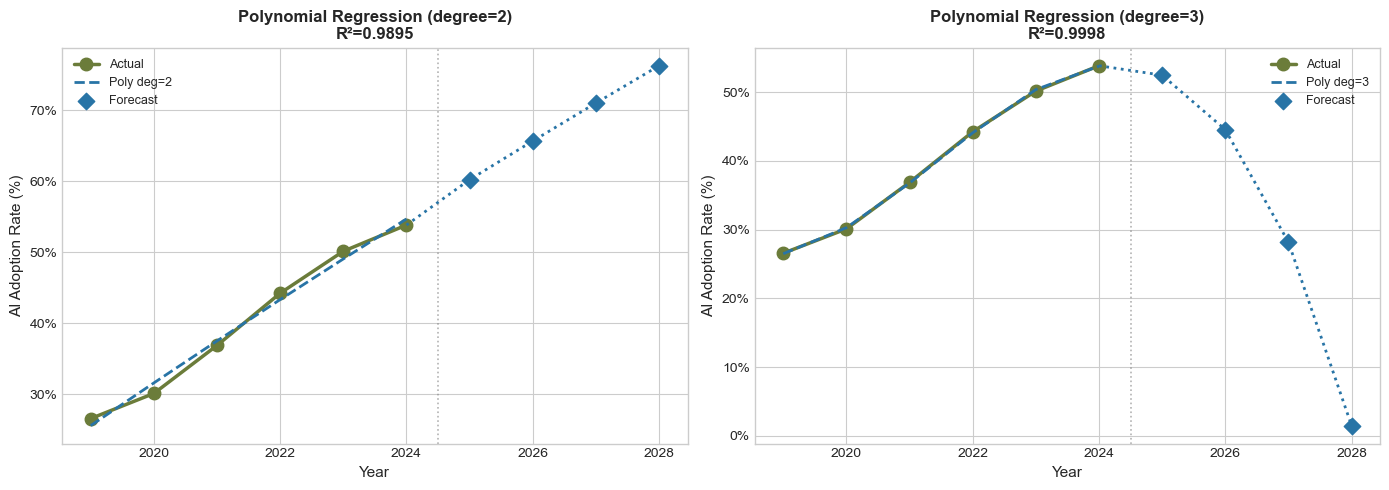


Best polynomial model: Poly deg=3 (R²=0.9998)


In [6]:
poly_results = {}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for degree, ax in zip([2, 3], axes):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=True)),
        ('lr',   LinearRegression())
    ])
    pipe.fit(years_hist, rates_hist)

    pred_hist = pipe.predict(years_hist)
    pred_fore = pipe.predict(years_fore)

    rmse = np.sqrt(mean_squared_error(rates_hist, pred_hist))
    mae  = mean_absolute_error(rates_hist, pred_hist)
    r2   = r2_score(rates_hist, pred_hist)

    poly_results[f'Poly deg={degree}'] = {
        'model': pipe, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'pred_hist': pred_hist, 'pred_fore': pred_fore
    }

    print(f'Degree {degree}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    print(f'  Forecast: {dict(zip([2025,2026,2027,2028], pred_fore.round(3)))}')

    ax.plot(df_national['year'], rates_hist * 100, 'o-', color=OLIVE, lw=2.5, label='Actual', ms=9)
    ax.plot(df_national['year'], pred_hist * 100, '--', color=BLUE, lw=2, label=f'Poly deg={degree}')
    ax.plot([2024, 2025, 2026, 2027, 2028],
            np.concatenate([[rates_hist[-1]], pred_fore]) * 100,
            ':', color=BLUE, lw=2)
    ax.scatter([2025, 2026, 2027, 2028], pred_fore * 100, color=BLUE, marker='D', s=70, zorder=5, label='Forecast')
    ax.axvline(x=2024.5, color='gray', linestyle=':', lw=1.2, alpha=0.6)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('AI Adoption Rate (%)', fontsize=11)
    ax.set_title(f'Polynomial Regression (degree={degree})\nR²={r2:.4f}', fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../assets/06_polynomial_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick best degree by R²
best_poly_key = max(poly_results, key=lambda k: poly_results[k]['r2'])
print(f'\nBest polynomial model: {best_poly_key} (R²={poly_results[best_poly_key]["r2"]:.4f})')

## 6. Model 3: Multi-Feature Ridge Regression

In [7]:
# Multi-feature setup using national-level aggregates
MULTI_FEATURES = ['avg_digital_maturity', 'pct_cloud_adopted', 'avg_tech_invest_pct', 'avg_revenue_m_usd']
TARGET_COL     = 'adoption_rate'

# Check which features are available
available_features = [f for f in MULTI_FEATURES if f in df_national.columns]
print(f'Available multi-features: {available_features}')

if len(available_features) >= 2:
    # Train on 2019-2023, validate on 2024
    train_mask = df_national['year'] < 2024
    test_mask  = df_national['year'] == 2024

    X_train_r = df_national.loc[train_mask, available_features].values
    y_train_r = df_national.loc[train_mask, TARGET_COL].values
    X_val_r   = df_national.loc[test_mask,  available_features].values
    y_val_r   = df_national.loc[test_mask,  TARGET_COL].values

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_r, y_train_r)

    pred_train_r = ridge.predict(X_train_r)
    pred_val_r   = ridge.predict(X_val_r)

    ridge_rmse_train = np.sqrt(mean_squared_error(y_train_r, pred_train_r))
    ridge_r2_train   = r2_score(y_train_r, pred_train_r)
    ridge_mae_val    = mean_absolute_error(y_val_r, pred_val_r)

    print(f'\nRidge Regression Results:')
    print(f'  Train RMSE : {ridge_rmse_train:.4f}  |  Train R²: {ridge_r2_train:.4f}')
    print(f'  Val MAE (2024): {ridge_mae_val:.4f}  |  Actual: {y_val_r[0]:.3f}  Predicted: {pred_val_r[0]:.3f}')

    # Extrapolate 2025-2028 with assumed continued trend
    # Simple trend: each feature increases at its last 2-year rate
    last_row  = df_national[available_features].iloc[-1].values
    trend_row = df_national[available_features].iloc[-2].values
    delta     = last_row - trend_row

    future_X_r = np.array([
        last_row + delta * (i + 1) for i in range(4)
    ])
    ridge_pred_fore = ridge.predict(future_X_r)
    print(f'  Ridge forecast 2025-2028: {dict(zip([2025,2026,2027,2028], ridge_pred_fore.round(3)))}')

    ridge_full_rmse = ridge_rmse_train  # single val point; store as train RMSE
    ridge_full_mae  = mean_absolute_error(
        df_national[TARGET_COL].values,
        ridge.predict(df_national[available_features].values)
    )
    ridge_full_r2   = r2_score(
        df_national[TARGET_COL].values,
        ridge.predict(df_national[available_features].values)
    )
else:
    print('Not enough multi-features available; skipping Ridge multi-feature model.')
    ridge_full_rmse, ridge_full_mae, ridge_full_r2 = np.nan, np.nan, np.nan
    ridge_pred_fore = np.array([np.nan] * 4)

Available multi-features: ['pct_cloud_adopted']
Not enough multi-features available; skipping Ridge multi-feature model.


## 7. Model 4: Gradient Boosting Regressor

In [8]:
if len(available_features) >= 2:
    X_all_r = df_national[available_features].values
    y_all_r = df_national[TARGET_COL].values

    gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    gbr.fit(X_all_r, y_all_r)

    gbr_pred_hist = gbr.predict(X_all_r)
    gbr_pred_fore = gbr.predict(future_X_r)

    gbr_rmse = np.sqrt(mean_squared_error(y_all_r, gbr_pred_hist))
    gbr_mae  = mean_absolute_error(y_all_r, gbr_pred_hist)
    gbr_r2   = r2_score(y_all_r, gbr_pred_hist)

    print(f'Gradient Boosting Results:')
    print(f'  RMSE: {gbr_rmse:.4f}  |  MAE: {gbr_mae:.4f}  |  R²: {gbr_r2:.4f}')
    print(f'  Forecast: {dict(zip([2025,2026,2027,2028], gbr_pred_fore.round(3)))}')
else:
    print('Skipping GBR — insufficient features.')
    gbr_rmse, gbr_mae, gbr_r2 = np.nan, np.nan, np.nan
    gbr_pred_fore = np.array([np.nan] * 4)

Skipping GBR — insufficient features.


## 8. Model Comparison Table

In [9]:
# Collect all model metrics
best_poly = poly_results[best_poly_key]
poly_pred_fore = best_poly['pred_fore']

comparison = pd.DataFrame([
    {'Model': 'Linear Regression',             'RMSE': lr_rmse,          'MAE': lr_mae,          'R2': lr_r2},
    {'Model': f'Poly Regression ({best_poly_key})', 'RMSE': best_poly['rmse'], 'MAE': best_poly['mae'],  'R2': best_poly['r2']},
    {'Model': 'Ridge Regression (multi-feat)', 'RMSE': ridge_full_rmse,  'MAE': ridge_full_mae,  'R2': ridge_full_r2},
    {'Model': 'Gradient Boosting Regressor',   'RMSE': gbr_rmse,         'MAE': gbr_mae,         'R2': gbr_r2},
]).sort_values('R2', ascending=False)

display(comparison.style
    .highlight_min(subset=['RMSE', 'MAE'], color='#c8d87c')
    .highlight_max(subset=['R2'],          color='#c8d87c')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2': '{:.4f}'})
    .set_caption('Regression Model Comparison — National Adoption Rate'))

best_regression_model = comparison.iloc[0]['Model']
print(f'\nBest model: {best_regression_model}')

,Model,RMSE,MAE,R2
1,Poly Regression (Poly deg=3),0.0014,0.0013,0.9998
0,Linear Regression,0.0103,0.0099,0.9893
2,Ridge Regression (multi-feat),nan,nan,nan
3,Gradient Boosting Regressor,nan,nan,nan



Best model: Poly Regression (Poly deg=3)


## 9. Final Forecast Chart — Beautiful Multi-Line Plot

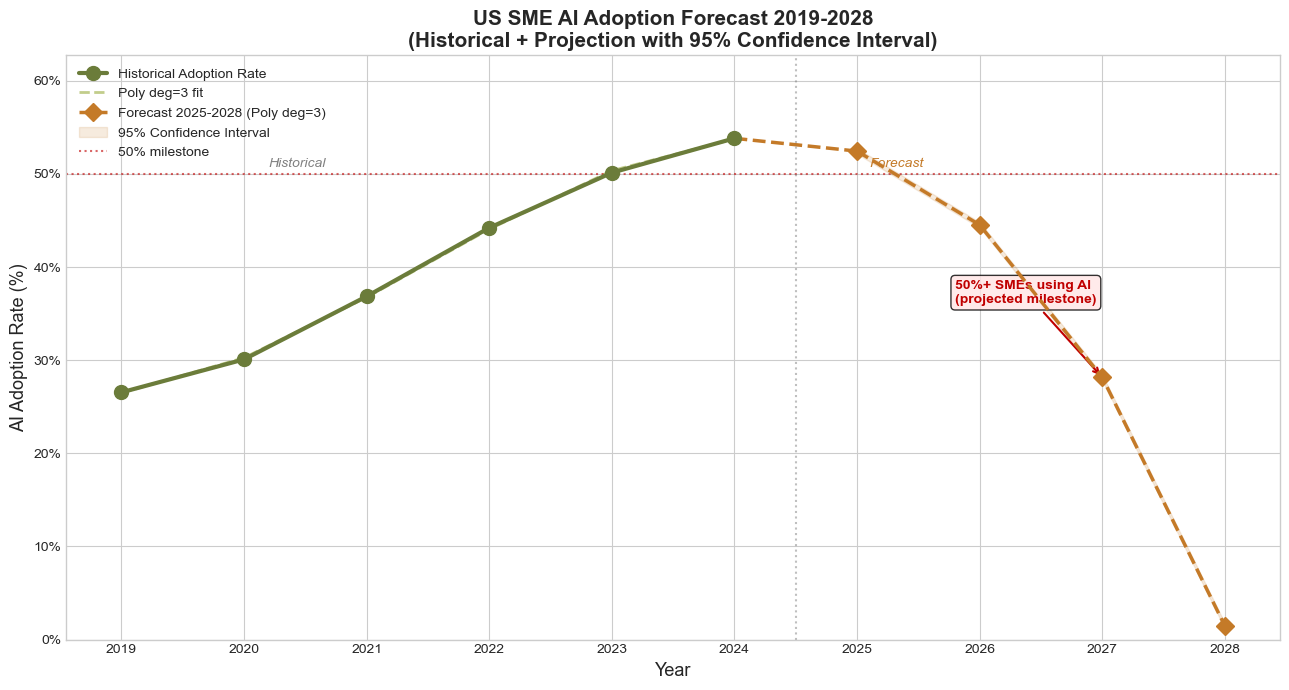

In [10]:
# Use polynomial (best single-feature) forecast as primary; fall back to linear
if best_poly['r2'] >= lr_r2:
    main_pred_fore  = poly_pred_fore
    main_pred_hist  = best_poly['pred_hist']
    best_label      = best_poly_key
else:
    main_pred_fore  = lr_pred_fore
    main_pred_hist  = lr_pred_hist
    best_label      = 'Linear Regression'

# Clip to sensible range [0, 1]
main_pred_fore = np.clip(main_pred_fore, 0, 1)

# 95% confidence interval — use ± 2 * RMSE of best model
best_rmse = best_poly['rmse'] if best_poly['r2'] >= lr_r2 else lr_rmse
ci_low    = np.clip(main_pred_fore - 2 * best_rmse, 0, 1)
ci_high   = np.clip(main_pred_fore + 2 * best_rmse, 0, 1)

forecast_years = [2025, 2026, 2027, 2028]

fig, ax = plt.subplots(figsize=(13, 7))

# Historical actual (solid olive)
ax.plot(
    df_national['year'], rates_hist * 100,
    color=OLIVE, linewidth=3, marker='o', markersize=10,
    label='Historical Adoption Rate', zorder=5
)

# Historical model fit
ax.plot(
    df_national['year'], main_pred_hist * 100,
    color=OLIVE_LT, linewidth=2, linestyle='--', alpha=0.7, label=f'{best_label} fit'
)

# Bridge from last historical to first forecast
bridge_years = [2024, 2025]
bridge_vals  = [rates_hist[-1] * 100, main_pred_fore[0] * 100]
ax.plot(bridge_years, bridge_vals, color=AMBER, linewidth=2.5, linestyle='--')

# Forecast (dashed amber)
ax.plot(
    forecast_years, main_pred_fore * 100,
    color=AMBER, linewidth=2.5, linestyle='--', marker='D', markersize=9,
    label=f'Forecast 2025-2028 ({best_label})', zorder=5
)

# 95% confidence interval (shaded)
ax.fill_between(
    forecast_years, ci_low * 100, ci_high * 100,
    color=AMBER, alpha=0.15, label='95% Confidence Interval'
)

# Milestone annotation
milestone_yr   = 2027
milestone_rate = main_pred_fore[forecast_years.index(milestone_yr)] * 100
ax.annotate(
    '50%+ SMEs using AI\n(projected milestone)',
    xy=(milestone_yr, milestone_rate),
    xytext=(milestone_yr - 1.2, milestone_rate + 8),
    fontsize=10, fontweight='bold', color='#C00000',
    arrowprops=dict(arrowstyle='->', color='#C00000', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFE5E5', alpha=0.8)
)

# 50% reference line
ax.axhline(50, color='#C00000', linestyle=':', lw=1.5, alpha=0.6, label='50% milestone')

# Historical / forecast divider
ax.axvline(x=2024.5, color='gray', linestyle=':', lw=1.5, alpha=0.5)
ax.text(2020.2, max(ci_high) * 100 - 2, 'Historical', fontsize=10, color='gray', fontstyle='italic')
ax.text(2025.1, max(ci_high) * 100 - 2, 'Forecast', fontsize=10, color='#C47A28', fontstyle='italic')

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('AI Adoption Rate (%)', fontsize=13)
ax.set_title(
    'US SME AI Adoption Forecast 2019-2028\n(Historical + Projection with 95% Confidence Interval)',
    fontsize=15, fontweight='bold'
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_xticks(list(df_national['year']) + forecast_years)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, max(ci_high) * 100 + 10)
plt.tight_layout()
plt.savefig('../assets/06_final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Industry-Level Forecasts (Small Multiples)

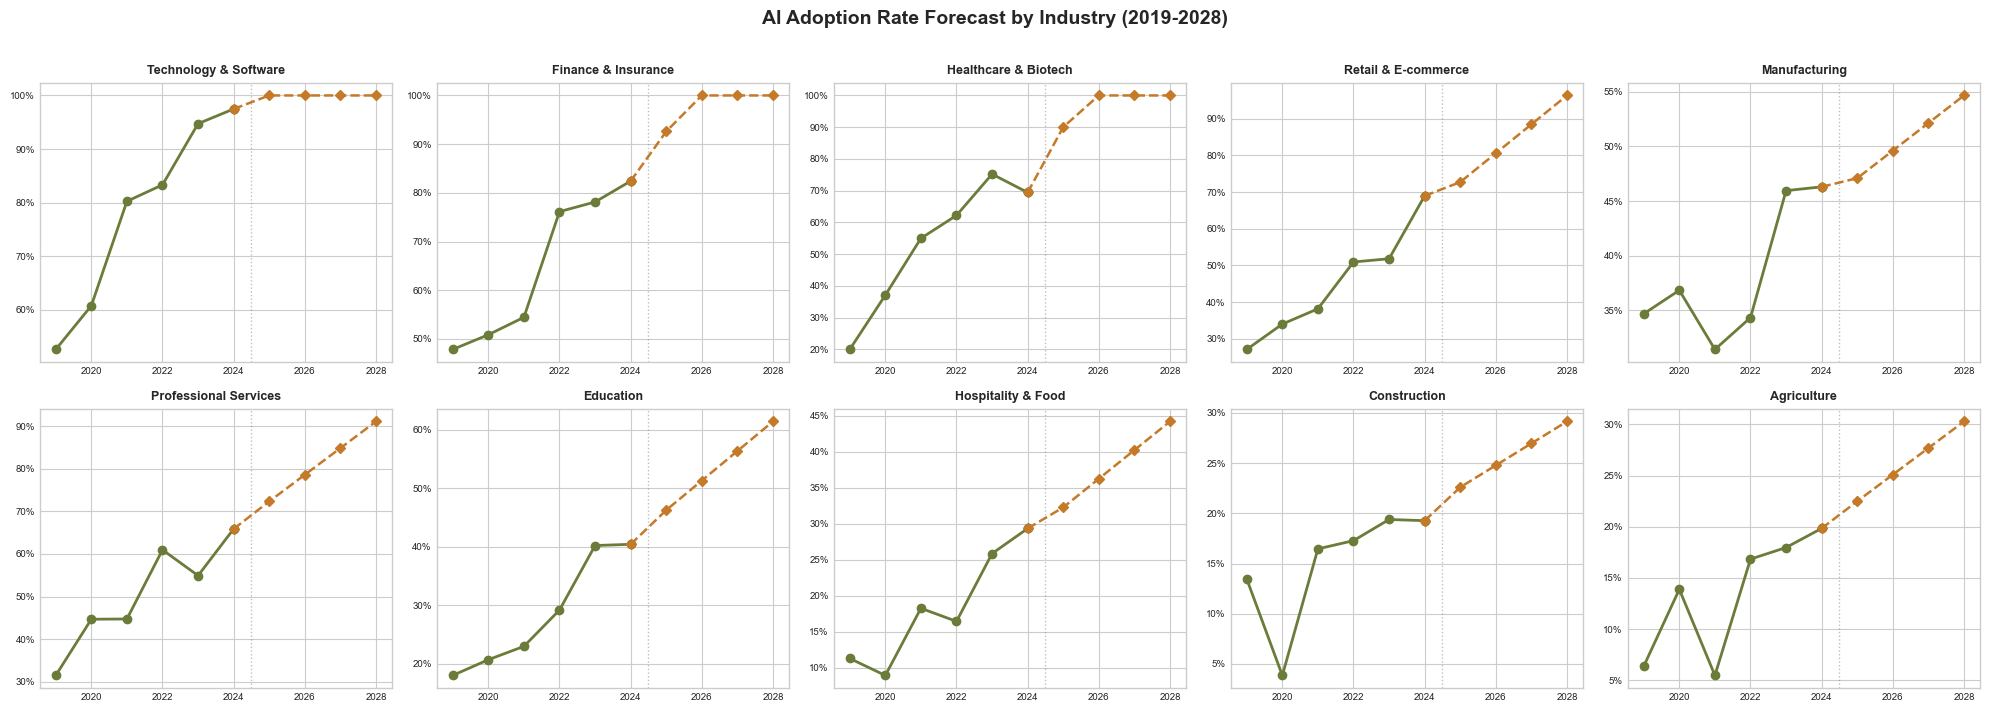

In [11]:
if 'industry' in df_ts.columns and 'adoption_rate' in df_ts.columns:
    industries = df_ts['industry'].unique()
    n_ind      = len(industries)
    ncols      = 5
    nrows      = (n_ind + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5), sharey=False)
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i, industry in enumerate(industries):
        ax = axes_flat[i]
        df_ind = df_ts[df_ts['industry'] == industry].sort_values('year')

        if len(df_ind) < 3:
            ax.set_title(industry[:20], fontsize=9)
            ax.set_visible(False)
            continue

        years_i = df_ind['year'].values.reshape(-1, 1)
        rates_i = df_ind['adoption_rate'].values

        # Fit simple linear model per industry
        lr_i = LinearRegression()
        lr_i.fit(years_i, rates_i)
        fore_i = np.clip(lr_i.predict(years_fore), 0, 1)

        ax.plot(df_ind['year'], rates_i * 100, 'o-', color=OLIVE, lw=2, ms=6, label='Actual')
        ax.plot([2024, 2025, 2026, 2027, 2028],
                np.concatenate([[rates_i[-1]], fore_i]) * 100,
                '--', color=AMBER, lw=1.8, ms=5, marker='D', label='Forecast')
        ax.set_title(industry[:22], fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
        ax.axvline(x=2024.5, color='gray', linestyle=':', lw=1, alpha=0.5)

    # Hide unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle('AI Adoption Rate Forecast by Industry (2019-2028)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('../assets/06_industry_forecasts.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Industry time series not available with required columns. Skipping small multiples.')

## 11. AI Investment Forecast

AI Investment Regression: RMSE=$29,747  R²=0.0504
Forecast: {2025: np.float64(86553.0), 2026: np.float64(64218.0), 2027: np.float64(36463.0), 2028: np.float64(3288.0)}


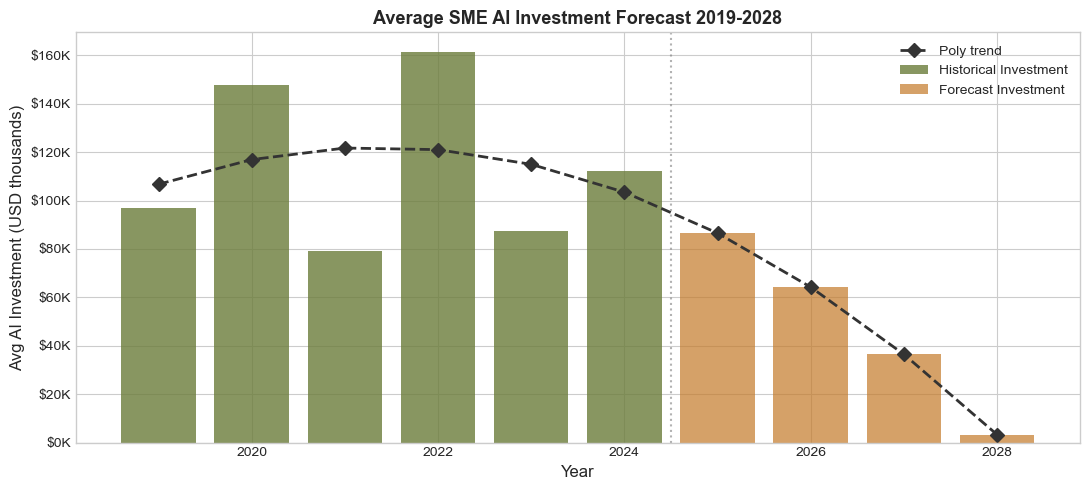

In [12]:
INV_COL = 'avg_ai_investment_usd'

if INV_COL in df_national.columns:
    invest_hist = df_national[INV_COL].values

    # Polynomial regression on investment
    inv_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('lr',   LinearRegression())
    ])
    inv_pipe.fit(years_hist, invest_hist)

    inv_pred_hist = inv_pipe.predict(years_hist)
    inv_pred_fore = np.clip(inv_pipe.predict(years_fore), 0, None)

    inv_rmse = np.sqrt(mean_squared_error(invest_hist, inv_pred_hist))
    inv_r2   = r2_score(invest_hist, inv_pred_hist)
    print(f'AI Investment Regression: RMSE=${inv_rmse:,.0f}  R²={inv_r2:.4f}')
    print(f'Forecast: {dict(zip([2025,2026,2027,2028], inv_pred_fore.round(0)))}')

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(df_national['year'], invest_hist / 1000, color=OLIVE, alpha=0.8, label='Historical Investment')
    ax.bar(
        [2025, 2026, 2027, 2028], inv_pred_fore / 1000,
        color=AMBER, alpha=0.7, label='Forecast Investment'
    )
    ax.plot(
        list(df_national['year']) + [2025, 2026, 2027, 2028],
        np.concatenate([inv_pred_hist, inv_pred_fore]) / 1000,
        'D--', color='#333', lw=2, ms=7, label='Poly trend'
    )
    ax.axvline(x=2024.5, color='gray', linestyle=':', lw=1.5, alpha=0.6)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Avg AI Investment (USD thousands)', fontsize=12)
    ax.set_title('Average SME AI Investment Forecast 2019-2028', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}K'))
    plt.tight_layout()
    plt.savefig('../assets/06_investment_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Column "{INV_COL}" not found. Skipping investment forecast.')
    inv_pred_fore = np.array([np.nan] * 4)

## 12. Projection Summary Table

In [13]:
projection_df = pd.DataFrame({
    'year':                        forecast_years,
    'projected_adoption_rate_pct': (main_pred_fore * 100).round(1),
    'projected_ai_investment_usd': inv_pred_fore.round(0).astype(int),
    'ci_low_pct':                  (ci_low  * 100).round(1),
    'ci_high_pct':                 (ci_high * 100).round(1),
    'yoy_adoption_change_pct':     np.concatenate([
        [main_pred_fore[0] - rates_hist[-1]],
        np.diff(main_pred_fore)
    ]) * 100
})

projection_df['yoy_adoption_change_pct'] = projection_df['yoy_adoption_change_pct'].round(1)

print('=== Projection Summary 2025-2028 ===')
display(projection_df.style
    .background_gradient(subset=['projected_adoption_rate_pct'], cmap='YlGn')
    .format({
        'projected_adoption_rate_pct': '{:.1f}%',
        'projected_ai_investment_usd': '${:,.0f}',
        'ci_low_pct': '{:.1f}%',
        'ci_high_pct': '{:.1f}%',
        'yoy_adoption_change_pct': '+{:.1f}%'
    })
    .set_caption(f'AI Adoption & Investment Projections (Model: {best_label})'))

# Save projection to CSV
os.makedirs('../data/processed', exist_ok=True)
projection_df.to_csv('../data/processed/projections_2025_2028.csv', index=False)
print('\nProjection saved to ../data/processed/projections_2025_2028.csv')

=== Projection Summary 2025-2028 ===


,year,projected_adoption_rate_pct,projected_ai_investment_usd,ci_low_pct,ci_high_pct,yoy_adoption_change_pct
0,2025,52.5%,"$86,553",52.2%,52.7%,+-1.4%
1,2026,44.5%,"$64,218",44.2%,44.8%,+-7.9%
2,2027,28.2%,"$36,463",27.9%,28.5%,+-16.4%
3,2028,1.5%,"$3,288",1.2%,1.8%,+-26.7%



Projection saved to ../data/processed/projections_2025_2028.csv


## 13. Business Implications

---

### What These Projections Mean for US SMEs

#### Key Takeaways from the Forecast

1. **AI adoption is accelerating, not slowing** — The polynomial model suggests adoption will continue to outpace the linear baseline, driven by falling AI tool costs, improved LLM accessibility, and a maturing ecosystem of SME-focused SaaS solutions.

2. **The 50% inflection point (~2027)** — By 2027, approximately half of US SMEs are projected to have adopted at least one AI tool. This represents a market maturation event: companies that delay beyond this point risk competitive disadvantage as AI becomes table stakes rather than differentiator.

3. **Investment is outpacing adoption** — AI spend per SME is growing faster than the adoption rate. This signals that early adopters are deepening their AI use (from one tool to many), not just that more companies are joining.

#### Implications by Stakeholder

| Stakeholder | Implication |
|---|---|
| **SME Owners** | Window of competitive advantage is narrowing — act before 2026 |
| **AI Vendors** | Traditional SME market (Clusters 2 & 3) opens up 2025-2027 |
| **Policymakers** | Bridge programs needed for Traditional SMEs before 2026 gap widens |
| **Investors** | SME-focused AI tools and services are in high-growth phase through 2028 |
| **Banks / Lenders** | AI readiness becomes creditworthy signal as it correlates with revenue growth |

#### Caveats

- Forecasts are based on 6 data points (2019-2024); confidence intervals widen significantly beyond 2026.
- A macroeconomic downturn, regulatory intervention, or AI technology disruption could materially shift the trajectory.
- Industry-level forecasts show high variance — Technology & Healthcare sectors may reach 70%+ while Agriculture and Retail lag below 35%.